# Assignment 6: Pix2Pix Gan  
**Student Name:** Lakshit Gupta  
**Enrollment No:** E23CSEU0992  
**Date:** February 17, 2026

## Objective
The objective of this lab is to understand and implement a Pix2Pix Gan Model using U-Net generator and PatchGan discrimnator and compare results with CNN  

# Component–I: Pix2Pix Gan Model using U-Net generator and PatchGan discrimnator

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import glob
import random


In [9]:
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))


GPU available: True
Device: Tesla T4


In [10]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz
!tar -xvf edges2shoes.tar.gz

Streaming output truncated to the last 5000 lines.
edges2shoes/train/46382_AB.jpg
edges2shoes/train/46383_AB.jpg
edges2shoes/train/46384_AB.jpg
edges2shoes/train/46385_AB.jpg
edges2shoes/train/46386_AB.jpg
edges2shoes/train/46387_AB.jpg
edges2shoes/train/46388_AB.jpg
edges2shoes/train/46389_AB.jpg
edges2shoes/train/4638_AB.jpg
edges2shoes/train/46390_AB.jpg
edges2shoes/train/46391_AB.jpg
edges2shoes/train/46392_AB.jpg
edges2shoes/train/449_AB.jpg
edges2shoes/train/44_AB.jpg
edges2shoes/train/45000_AB.jpg
edges2shoes/train/45001_AB.jpg
edges2shoes/train/45002_AB.jpg
edges2shoes/train/45003_AB.jpg
edges2shoes/train/45004_AB.jpg
edges2shoes/train/45005_AB.jpg
edges2shoes/train/45006_AB.jpg
edges2shoes/train/45007_AB.jpg
edges2shoes/train/45008_AB.jpg
edges2shoes/train/45009_AB.jpg
edges2shoes/train/4500_AB.jpg
edges2shoes/train/45010_AB.jpg
edges2shoes/train/45011_AB.jpg
edges2shoes/train/45012_AB.jpg
edges2shoes/train/45013_AB.jpg
edges2shoes/train/45687_AB.jpg
edges2shoes/train/45688_AB

In [11]:
os.makedirs("dataset/train/edges", exist_ok=True)
os.makedirs("dataset/train/real", exist_ok=True)
os.makedirs("dataset/test/edges", exist_ok=True)
os.makedirs("dataset/test/real", exist_ok=True)


In [12]:
def split_images(input_folder, edge_out, real_out):
    images = glob.glob(input_folder + "/*.jpg")

    for img_path in images:
        img = Image.open(img_path)
        w, h = img.size

        edge = img.crop((0, 0, w//2, h))
        real = img.crop((w//2, 0, w, h))

        name = os.path.basename(img_path)

        edge.save(os.path.join(edge_out, name))
        real.save(os.path.join(real_out, name))


In [13]:
split_images("edges2shoes/train", "dataset/train/edges", "dataset/train/real")
split_images("edges2shoes/test", "dataset/test/edges", "dataset/test/real")


In [14]:
print("Train edges:", len(os.listdir("dataset/train/edges")))
print("Train real:", len(os.listdir("dataset/train/real")))
print("Test edges:", len(os.listdir("dataset/test/edges")))
print("Test real:", len(os.listdir("dataset/test/real")))


Train edges: 49825
Train real: 49825
Test edges: 0
Test real: 0


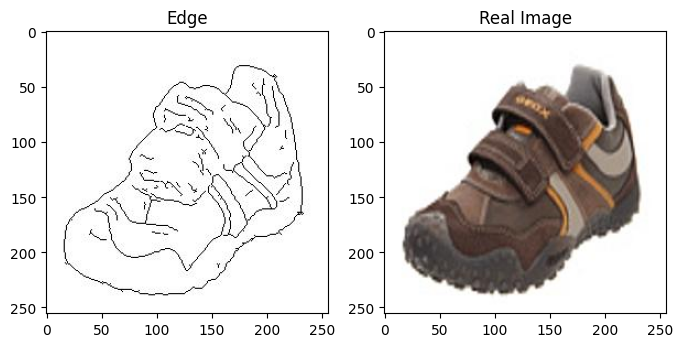

In [15]:
sample = random.choice(os.listdir("dataset/train/edges"))

edge = Image.open("dataset/train/edges/" + sample)
real = Image.open("dataset/train/real/" + sample)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Edge")
plt.imshow(edge)

plt.subplot(1,2,2)
plt.title("Real Image")
plt.imshow(real)


In [16]:
class EdgesDataset(Dataset):
    def __init__(self, root_dir):
        self.edge_dir = os.path.join(root_dir, "edges")
        self.real_dir = os.path.join(root_dir, "real")
        self.files = os.listdir(self.edge_dir)

        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        edge_path = os.path.join(self.edge_dir, self.files[idx])
        real_path = os.path.join(self.real_dir, self.files[idx])

        edge = Image.open(edge_path).convert("RGB")
        real = Image.open(real_path).convert("RGB")

        edge = self.transform(edge)
        real = self.transform(real)

        return edge, real


In [17]:
class UNetBlockDown(nn.Module):
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetBlockUp(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)

class GeneratorUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = UNetBlockDown(3, 64, normalize=False)
        self.down2 = UNetBlockDown(64, 128)
        self.down3 = UNetBlockDown(128, 256)
        self.down4 = UNetBlockDown(256, 512)

        self.up1 = UNetBlockUp(512, 256)
        self.up2 = UNetBlockUp(512, 128)
        self.up3 = UNetBlockUp(256, 64)
        self.up4 = nn.ConvTranspose2d(128, 3, 4, 2, 1)

        self.tanh = nn.Tanh()

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)

        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], 1))
        u3 = self.up3(torch.cat([u2, d2], 1))
        u4 = self.up4(torch.cat([u3, d1], 1))

        return self.tanh(u4)


In [18]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2))
            return layers

        self.model = nn.Sequential(
            *block(6, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, edge, real):
        x = torch.cat([edge, real], 1)
        return self.model(x)


In [19]:
class CNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = GeneratorUNet().to(device)
D = Discriminator().to(device)
CNN_model = CNNBaseline().to(device)

lr = 0.0002

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
opt_CNN = optim.Adam(CNN_model.parameters(), lr=lr)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()


In [21]:
train_dataset = EdgesDataset("dataset/train")
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)


Epoch 0 | Batch 0 | D:0.718 G:91.000


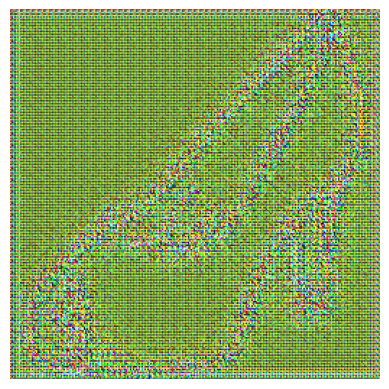

Epoch 0 | Batch 200 | D:0.731 G:15.247


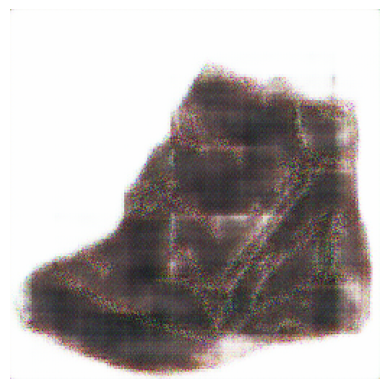

Epoch 0 | Batch 400 | D:0.450 G:28.980


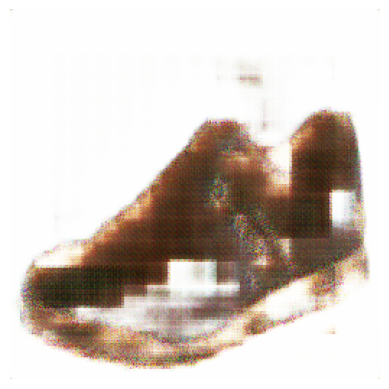

Epoch 0 | Batch 600 | D:0.192 G:31.093


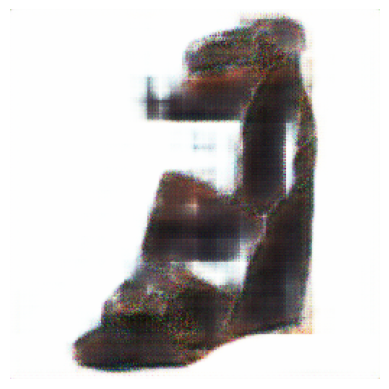

Epoch 0 | Batch 800 | D:0.109 G:20.177


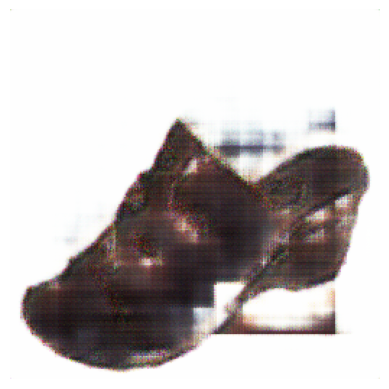

Epoch 0 | Batch 1000 | D:0.285 G:41.353


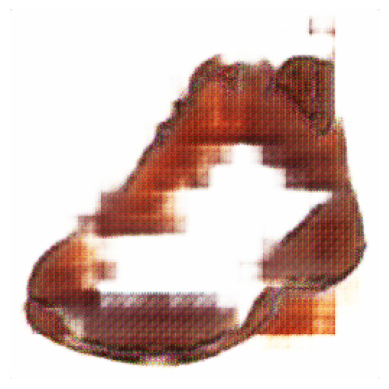

Epoch 0 | Batch 1200 | D:0.213 G:19.896


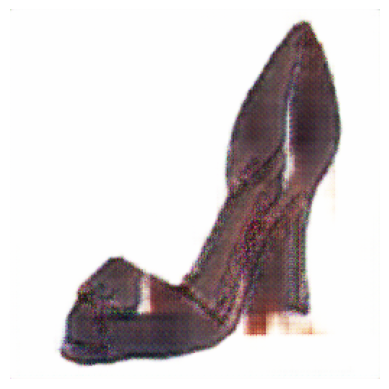

Epoch 0 | Batch 1400 | D:0.308 G:16.114


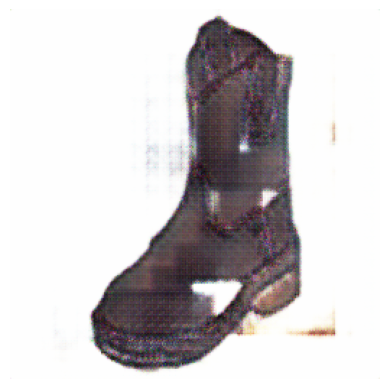

Epoch 0 | Batch 1600 | D:0.775 G:13.700


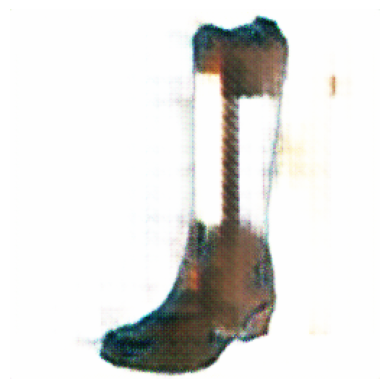

Epoch 0 | Batch 1800 | D:0.599 G:38.335


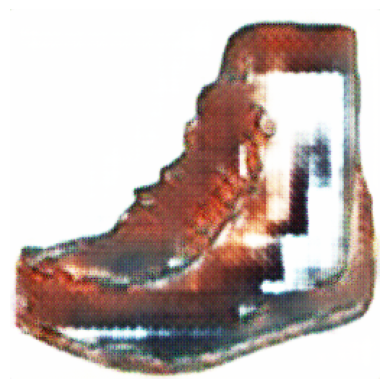

Epoch 0 | Batch 2000 | D:0.420 G:20.224


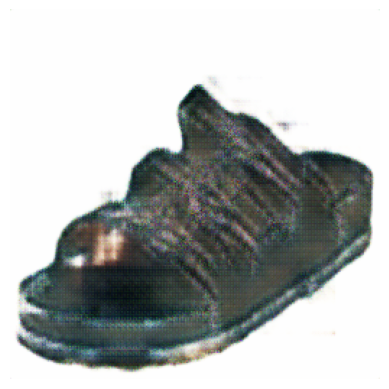

Epoch 0 | Batch 2200 | D:1.091 G:9.151


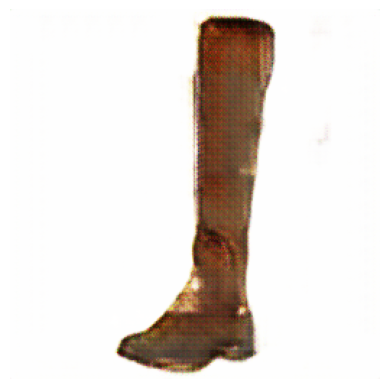

Epoch 0 | Batch 2400 | D:0.829 G:17.332


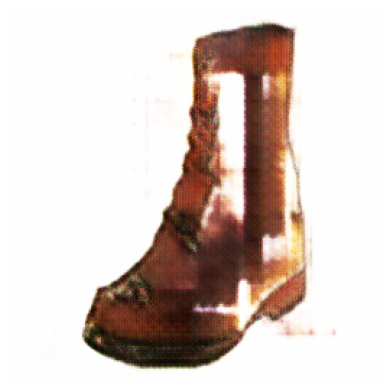

Epoch 0 | Batch 2600 | D:0.236 G:21.901


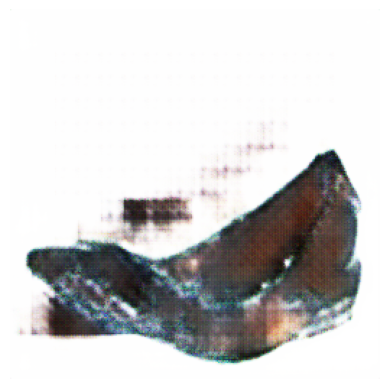

Epoch 0 | Batch 2800 | D:0.429 G:20.215


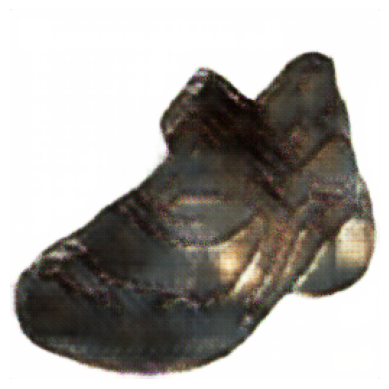

Epoch 0 | Batch 3000 | D:0.492 G:16.639


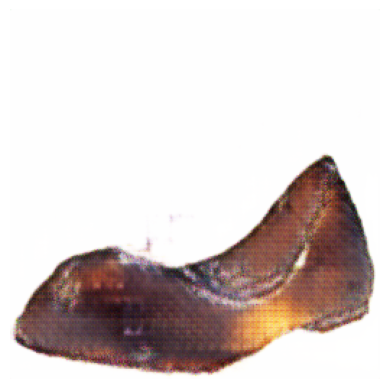

Epoch 0 | Batch 3200 | D:0.076 G:33.452


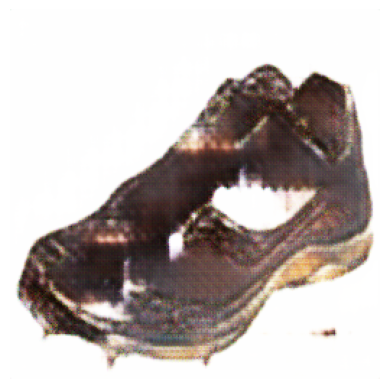

Epoch 0 | Batch 3400 | D:0.649 G:17.184


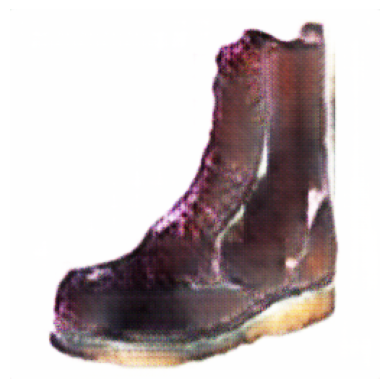

Epoch 0 | Batch 3600 | D:0.328 G:18.125


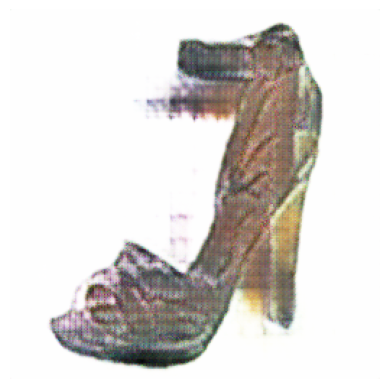

Epoch 0 | Batch 3800 | D:0.204 G:30.893


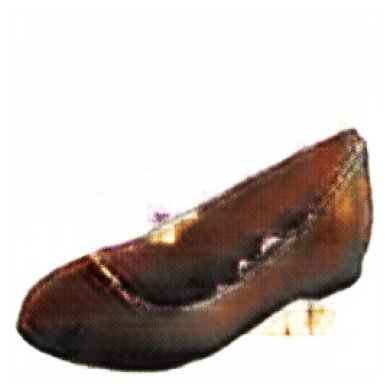

Epoch 0 | Batch 4000 | D:0.402 G:12.315


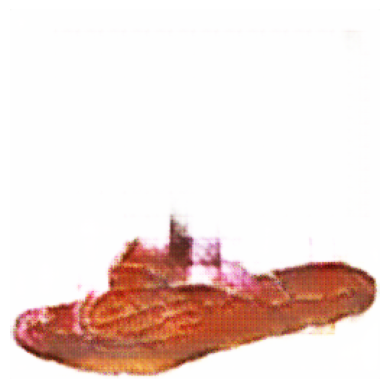

Epoch 0 | Batch 4200 | D:0.242 G:9.274


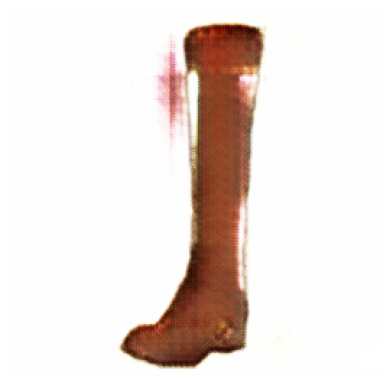

Epoch 0 | Batch 4400 | D:0.182 G:19.913


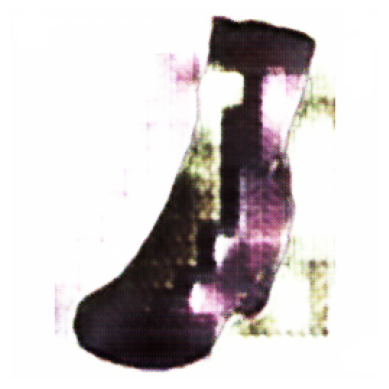

Epoch 0 | Batch 4600 | D:0.862 G:5.077


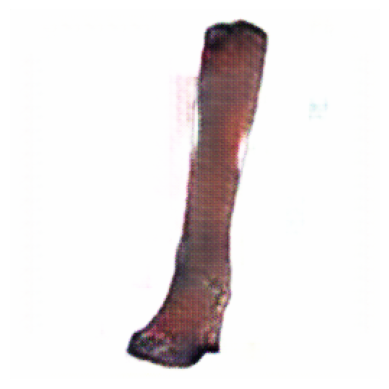

Epoch 0 | Batch 4800 | D:0.068 G:26.024


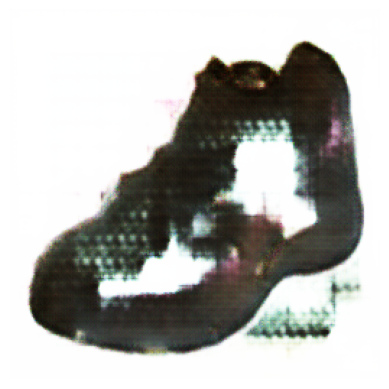

Epoch 0 | Batch 5000 | D:0.115 G:34.804


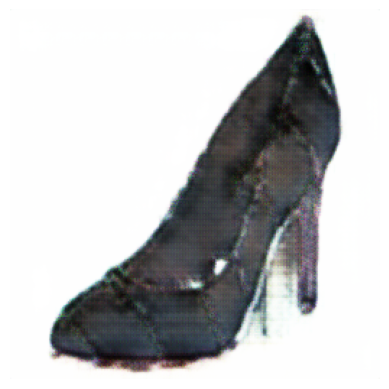

Epoch 0 | Batch 5200 | D:0.265 G:15.777


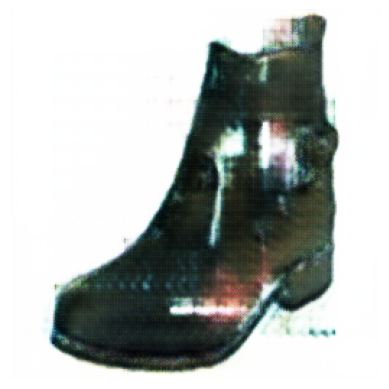

Epoch 0 | Batch 5400 | D:0.430 G:21.507


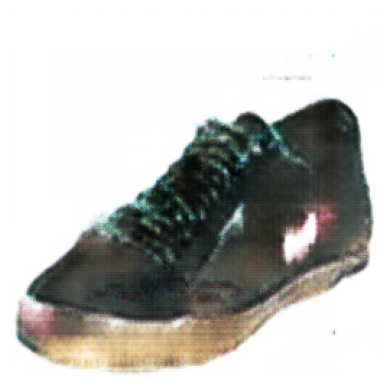

Epoch 0 | Batch 5600 | D:0.100 G:21.845


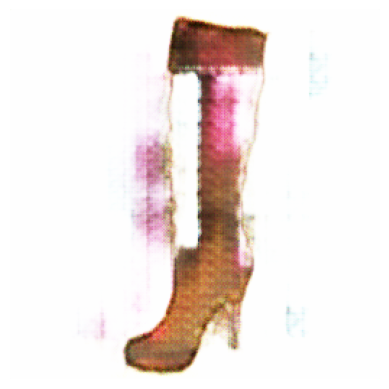

Epoch 0 | Batch 5800 | D:0.129 G:22.981


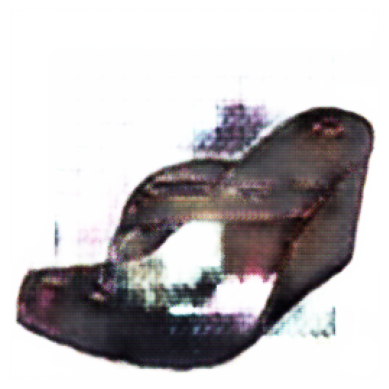

Epoch 0 | Batch 6000 | D:0.093 G:47.767


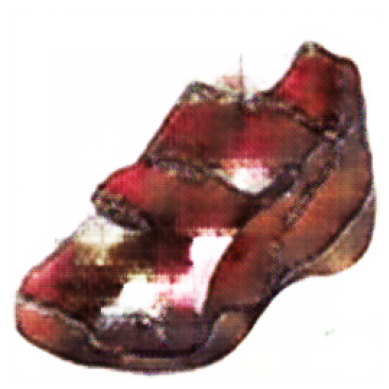

Epoch 0 | Batch 6200 | D:0.371 G:25.525


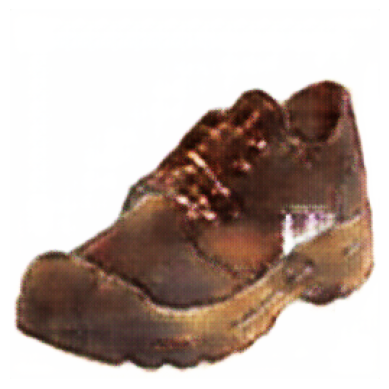

Epoch 0 | Batch 6400 | D:0.948 G:17.571


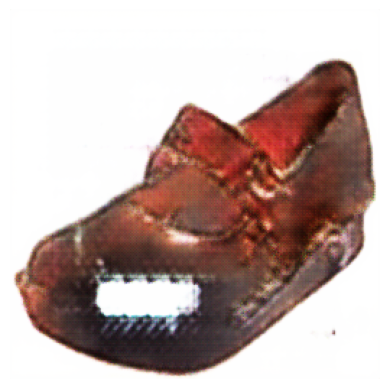

Epoch 0 | Batch 6600 | D:0.033 G:34.359


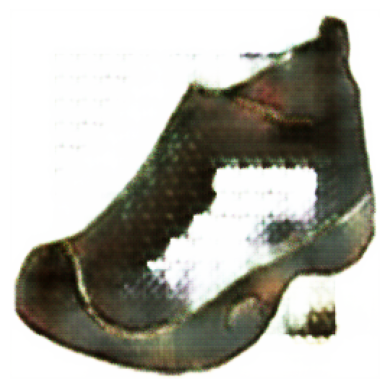

Epoch 0 | Batch 6800 | D:0.094 G:20.695


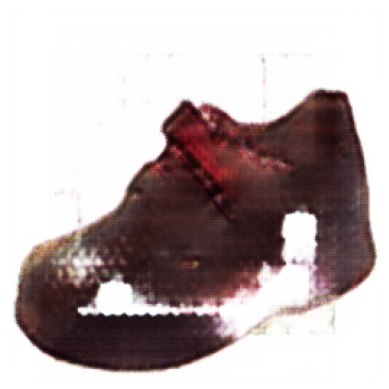

In [ ]:
epochs = 30
lambda_L1 = 100

G_losses = []
D_losses = []

os.makedirs("outputs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(epochs):
    for i, (edge, real) in enumerate(train_loader):

        edge, real = edge.to(device), real.to(device)

        # Train Discriminator
        fake = G(edge)

        pred_real = D(edge, real)
        pred_fake = D(edge, fake.detach())

        loss_D = (
            criterion_GAN(pred_real, torch.ones_like(pred_real)) +
            criterion_GAN(pred_fake, torch.zeros_like(pred_fake))
        ) / 2

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        pred_fake = D(edge, fake)

        loss_G = (
            criterion_GAN(pred_fake, torch.ones_like(pred_fake)) +
            criterion_L1(fake, real) * lambda_L1
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # Train CNN baseline
        cnn_out = CNN_model(edge)
        loss_cnn = criterion_L1(cnn_out, real)

        opt_CNN.zero_grad()
        loss_cnn.backward()
        opt_CNN.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        if i % 200 == 0:
            print(f"Epoch {epoch} | Batch {i} | D:{loss_D:.3f} G:{loss_G:.3f}")

            # show generated sample
            img = make_grid(fake[:1], normalize=True)
            plt.imshow(img.permute(1,2,0).cpu())
            plt.axis("off")
            plt.show()

    # Save checkpoint
    torch.save(G.state_dict(), f"checkpoints/G_epoch_{epoch}.pth")


In [ ]:
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

In [ ]:
test_dataset = EdgesDataset("dataset/test")
test_loader = DataLoader(test_dataset, batch_size=1)

G.eval()

with torch.no_grad():
    for i,(edge,real) in enumerate(test_loader):
        edge = edge.to(device)
        fake = G(edge)
        save_image(fake, f"test_outputs/{i}.png")
